# Frequentist Inference Case Study - Part B

## Learning objectives

Welcome to Part B of the Frequentist inference case study! The purpose of this case study is to help you apply the concepts associated with Frequentist inference in Python. In particular, you'll practice writing Python code to apply the following statistical concepts: 
* the _z_-statistic
* the _t_-statistic
* the difference and relationship between the two
* the Central Limit Theorem, including its assumptions and consequences
* how to estimate the population mean and standard deviation from a sample
* the concept of a sampling distribution of a test statistic, particularly for the mean
* how to combine these concepts to calculate a confidence interval

In the previous notebook, we used only data from a known normal distribution. **You'll now tackle real data, rather than simulated data, and answer some relevant real-world business problems using the data.**

## Hospital medical charges

Imagine that a hospital has hired you as their data scientist. An administrator is working on the hospital's business operations plan and needs you to help them answer some business questions. 

In this assignment notebook, you're going to use frequentist statistical inference on a data sample to answer the questions:
* has the hospital's revenue stream fallen below a key threshold?
* are patients with insurance really charged different amounts than those without?

Answering that last question with a frequentist approach makes some assumptions, and requires some knowledge, about the two groups.

We are going to use some data on medical charges obtained from [Kaggle](https://www.kaggle.com/easonlai/sample-insurance-claim-prediction-dataset). 

For the purposes of this exercise, assume the observations are the result of random sampling from our single hospital. Recall that in the previous assignment, we introduced the Central Limit Theorem (CLT), and its consequence that the distributions of sample statistics approach a normal distribution as $n$ increases. The amazing thing about this is that it applies to the sampling distributions of statistics that have been calculated from even highly non-normal distributions of data! Recall, also, that hypothesis testing is very much based on making inferences about such sample statistics. You're going to rely heavily on the CLT to apply frequentist (parametric) tests to answer the questions in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from numpy.random import seed
medical = pd.read_csv('insurance2.csv')

In [2]:
medical.shape

(1338, 8)

In [3]:
medical.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


__Q1:__ Plot the histogram of charges and calculate the mean and standard deviation. Comment on the appropriateness of these statistics for the data.

__A:__ The distribution of charges is right-skewed, with some very high values. Because the mean and standard deviation can be affected by these extreme values, they may not describe the data very well. The median and IQR would be better for showing the typical charge and the spread of the data.


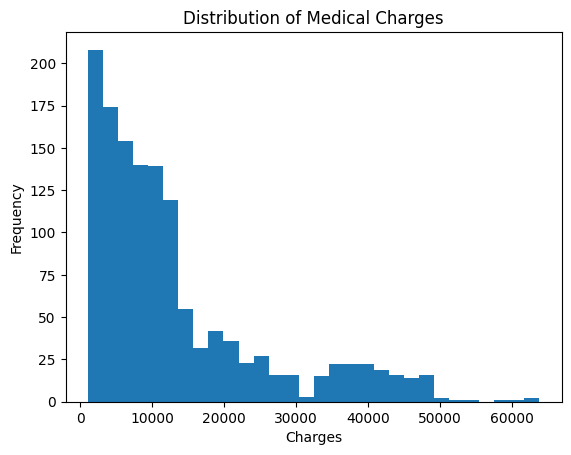

In [4]:
import matplotlib.pyplot as plt

plt.hist(medical['charges'], bins=30)
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Medical Charges')
plt.show()

In [5]:
mean_charges = medical['charges'].mean()
std_charges = medical['charges'].std()

print("Mean:", mean_charges)
print("Standard deviation:", std_charges)

Mean: 13270.422265141257
Standard deviation: 12110.011236694001


__Q2:__ The administrator is concerned that the actual average charge has fallen below 12,000, threatening the hospital's operational model. On the assumption that these data represent a random sample of charges, how would you justify that these data allow you to answer that question? And what would be the most appropriate frequentist test, of the ones discussed so far, to apply?

__A:__ Since the data are assumed to be a random sample, we can use the sample to make inferences about the population of hospital charges. We want to determine whether the population mean charge is below 12,000 dollars. The most appropriate test is a one-sample t-test, using a one-tailed test because we are specifically testing whether the mean is less than 12,000 dollars.

__Q3:__ Given the nature of the administrator's concern, what is the appropriate confidence interval in this case? A ***one-sided*** or ***two-sided*** interval? (Refresh your understanding of this concept on p. 399 of the *AoS*). Calculate the critical value and the relevant 95% confidence interval for the mean, and comment on whether the administrator should be concerned.

__A:__ A one-sided confidence interval is appropriate because the administrator is specifically concerned about whether the average charge has fallen below 12,000 dollars. The sample mean is about 13,270 dollars, and the lower bound of the 95% one-sided confidence interval is about 12,725 dollars. Since the lower bound is above 12,000 dollars, the data do not suggest that the true average charge has fallen below 12,000 dollars. Therefore, the administrator's concern is not supported by this confidence interval.


In [6]:
# Calculate the sample size and degrees of freedom
n = len(medical['charges'])
df = n - 1

# Calculate the critical t-value for a 95% one-sided confidence interval
t_critical = t.ppf(0.95, df)

print("Critical t-value:", t_critical)

Critical t-value: 1.6459941145571317


In [7]:
# Calculate the sample mean and standard error
mean_charges = medical['charges'].mean()
std_charges = medical['charges'].std()
standard_error = std_charges / (n ** 0.5)

# Calculate the lower bound of the 95% one-sided confidence interval
lower_bound = mean_charges - t_critical * standard_error

print("Sample mean:", mean_charges)
print("95% one-sided confidence interval: (", lower_bound, ", infinity)")

Sample mean: 13270.422265141257
95% one-sided confidence interval: ( 12725.48718381623 , infinity)


In [8]:
# Compare the lower confidence bound with 12,000 dollars
if lower_bound < 12000:
    print("The lower confidence bound is below 12,000 dollars.")
    print("The administrator's concern is supported by the confidence interval.")
else:
    print("The lower confidence bound is above 12,000 dollars.")
    print("The confidence interval does not support the concern that the mean is below 12,000 dollars.")

The lower confidence bound is above 12,000 dollars.
The confidence interval does not support the concern that the mean is below 12,000 dollars.


The administrator then wants to know whether people with insurance really are charged a different amount to those without.

__Q4:__ State the null and alternative hypothesis here. Use the _t_-test for the difference between means, where the pooled standard deviation of the two groups is given by:
\begin{equation}
s_p = \sqrt{\frac{(n_0 - 1)s^2_0 + (n_1 - 1)s^2_1}{n_0 + n_1 - 2}}
\end{equation}

and the *t*-test statistic is then given by:

\begin{equation}
t = \frac{\bar{x}_0 - \bar{x}_1}{s_p \sqrt{1/n_0 + 1/n_1}}.
\end{equation}

(If you need some reminding of the general definition of ***t-statistic***, check out the definition on p. 404 of *AoS*). 

What assumption about the variances of the two groups are we making here?

__A:__ 
- Null hypothesis: There is no difference in the average charges between people with insurance and people without insurance.

- Alternative hypothesis: There is a difference in the average charges between people with insurance and people without insurance.

This is a two-sided test because we are interested in whether the two averages are different, without specifying which group has the higher charge.

The pooled t-test assumes that the two groups have approximately equal variances. In other words, we assume that the spread of charges is similar in the insured and uninsured groups.

__Q5:__ Perform this hypothesis test both manually, using the above formulae, and then using the appropriate function from [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html#statistical-tests) (hint, you're looking for a function to perform a _t_-test on two independent samples). For the manual approach, calculate the value of the test statistic and then its probability (the p-value). Verify you get the same results from both.

__A:__ The manual calculation and `scipy.stats.ttest_ind()` produced the same results, confirming that the calculations were correct. The `scipy.stats` function is much easier because we only need to pass the two groups of data to it.


In [9]:
# Separate the charges into insured and uninsured groups
insured = medical[medical['insuranceclaim'] == 1]['charges']
uninsured = medical[medical['insuranceclaim'] == 0]['charges']

# Check the number of observations in each group
print("Insured group:", len(insured))
print("Uninsured group:", len(uninsured))

Insured group: 783
Uninsured group: 555


In [10]:
# Calculate the sample sizes
n1 = len(insured)
n0 = len(uninsured)

# Calculate the sample standard deviations
s1 = insured.std()
s0 = uninsured.std()

# Calculate the pooled standard deviation
sp = np.sqrt(
    ((n1 - 1) * s1**2 + (n0 - 1) * s0**2)
    / (n1 + n0 - 2)
)

print("Pooled standard deviation:", sp)

Pooled standard deviation: 11520.034268775262


In [11]:
# Calculate the difference between the two group means
mean_difference = insured.mean() - uninsured.mean()

# Calculate the t-statistic
t_stat = mean_difference / (
    sp * np.sqrt((1 / n1) + (1 / n0))
)

# Calculate degrees of freedom
df = n1 + n0 - 2

# Calculate the two-sided p-value
p_value = 2 * t.cdf(-abs(t_stat), df)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 11.89329903087671
p-value: 4.461230231620972e-31


In [12]:
from scipy.stats import ttest_ind

# Perform the independent two-sample t-test
result = ttest_ind(insured, uninsured, equal_var=True)

print("t-statistic:", result.statistic)
print("p-value:", result.pvalue)

t-statistic: 11.893299030876712
p-value: 4.461230231620717e-31


Congratulations! Hopefully you got the exact same numerical results. This shows that you correctly calculated the numbers by hand. Secondly, you used the correct function and saw that it's much easier to use. All you need to do is pass your data to it.

__Q6:__ Conceptual question: look through the documentation for statistical test functions in scipy.stats. You'll see the above _t_-test for a sample, but can you see an equivalent one for performing a *z*-test from a sample? Comment on your answer.

__A:__ There is no specific z-test function in `scipy.stats` like there is for the t-test. SciPy provides functions for the normal distribution, so a z-test can be calculated manually, but there is no dedicated `ztest()` function in the documentation.


## Learning outcomes

Having completed this project notebook, you now have good hands-on experience:
* using the central limit theorem to help you apply frequentist techniques to answer questions that pertain to very non-normally distributed data from the real world
* performing inference using such data to answer business questions
* forming a hypothesis and framing the null and alternative hypotheses
* testing this using a _t_-test